In [1]:
from ortools.sat.python import cp_model

##### Sets & Indices

- $C$: set of courses ($c \in C$)
- $T$: set of semesters ($t \in T$)
- $P\_strict$: set of strict prerequisite pairs $(c_1, c_2)$
- $P\_co$: set of Co-prerequisite pairs $(c_1, c_2)$

##### Parameters

- $q_c$: credit units of course $c$
- $L_{\min}$: minimum credits allowed per semester
- $L_{\max}$: maximum credits allowed per semester

---

##### Decision Variables

$$
x_{ct} = \begin{cases} 1 & \text{if course } c \text{ is assigned to semester } t \\ 0 & \text{otherwise} \end{cases}
$$

##### Complete Model

$$
\boxed{
\begin{aligned}
\min \quad & L^{max} - L^{min} \\[2mm]
\text{s.t.} \quad & \sum_{t \in T} x_{ct} = 1 && \forall c \in C \\[2mm]
& L_t = \sum_{c \in C} q_c x_{ct} && \forall t \in T \\[2mm]
& L_{\min} \le L_t \le L_{\max} && \forall t \in T \\[2mm]
& \sum_{t \in T} t \cdot x_{c_1,t} + 1 \le \sum_{t \in T} t \cdot x_{c_2,t} && \forall (c_1,c_2) \in P\_strict \\[2mm]
& \sum_{t \in T} t \cdot x_{c_1,t} \le \sum_{t \in T} t \cdot x_{c_2,t} && \forall (c_1,c_2) \in P\_co \\[2mm]
& L_t \le L^{max} && \forall t \in T \\[2mm]
& L_t \ge L^{min} && \forall t \in T \\[2mm]
& x_{ct} \in \{0,1\} && \forall c \in C, \; t \in T
\end{aligned}
}
$$

In [2]:
import pandas as pd

In [18]:
df = pd.read_excel("./data/IE_Curriculum_EN.xlsx")

In [26]:
df.sample(n=5)

,Group,Course,Units,Strict_Prereq,Co_Prereq
52,Elective,Financial Management,2,Principles of Accounting and Costing,NaN
14,Basic,Physics 1,3,NaN,Calculus 1
49,Elective,Transportation Planning,3,Operations Research 1,NaN
37,Core,Industrial Plant Layout,3,Work and Time Study; Industrial Drawing; Produ...,NaN
60,Elective,Machine Shop Workshop 2,1,Production Methods,NaN


In [27]:
C = df["Course"].tolist()
q = df["Units"].tolist()
course_to_idx = {name: i for i, name in enumerate(df["Course"])}

num_c = range(len(C))
L_max = 20
L_min = 12

In [28]:
T = list(range(1,9))

P_strict = []
P_co = []
for _, row in df.iterrows():
    if pd.notna(row["Strict_Prereq"]) and str(row["Strict_Prereq"]).strip() != "":
        for prereq in str(row["Strict_Prereq"]).split(";"):
            c1 = course_to_idx[prereq.strip()]
            c2 = course_to_idx[row["Course"]]
            P_strict.append((c1,c2))
            
    if pd.notna(row["Co_Prereq"]) and str(row["Co_Prereq"]).strip() != "":
        for coreq in str(row["Co_Prereq"]).split(";"):
            co1 = course_to_idx[coreq.strip()]
            co2 = course_to_idx[row["Course"]]
            P_co.append((co1,co2))

In [29]:
model = cp_model.CpModel()

In [30]:
x = {
   (c,t): model.NewBoolVar(f"[{c},{t}]") 
   for c in num_c
   for t in T
}


In [31]:
for c in num_c:
    model.AddExactlyOne([x[c,t] for t in T])

In [32]:
Load = {t: sum(q[c]*x[c,t] for c in num_c) for t in T}
for t in T:
    model.Add(Load[t]<=L_max)
    model.Add(Load[t]>=L_min)

In [33]:
for c1,c2 in P_strict:
    pre_list = []
    cur_list = []
    for t in T:
        pre_list.append(t*x[c1,t])
        cur_list.append(t*x[c2,t])
    model.Add(sum(pre_list) + 1 <= sum(cur_list))

In [34]:
for c1,c2 in P_co:
    pco_list = []
    cor_list = []
    for t in T:
        pco_list.append(t*x[c1,t])
        cor_list.append(t*x[c2,t])
    model.Add(sum(pco_list) <= sum(cor_list))

In [35]:
Max_Load = model.NewIntVar(L_min, L_max, 'Max_Load')
Min_Load = model.NewIntVar(L_min, L_max, 'Min_Load')

for t in T:
    model.Add(Max_Load >= Load[t])
    model.Add(Min_Load <= Load[t])

model.Minimize(Max_Load - Min_Load)

In [36]:
solver = cp_model.CpSolver()
status = solver.Solve(model)

print(status)
print("Maximum Load:", solver.Value(Max_Load))
print("Minimum Load:", solver.Value(Min_Load))
print("Difference:", solver.Value(Max_Load) - solver.Value(Min_Load))
[solver.Value(Load[t]) for t in T]

CpSolverStatus.OPTIMAL
Maximum Load: 19
Minimum Load: 18
Difference: 1


[19, 19, 19, 19, 19, 19, 18, 19]

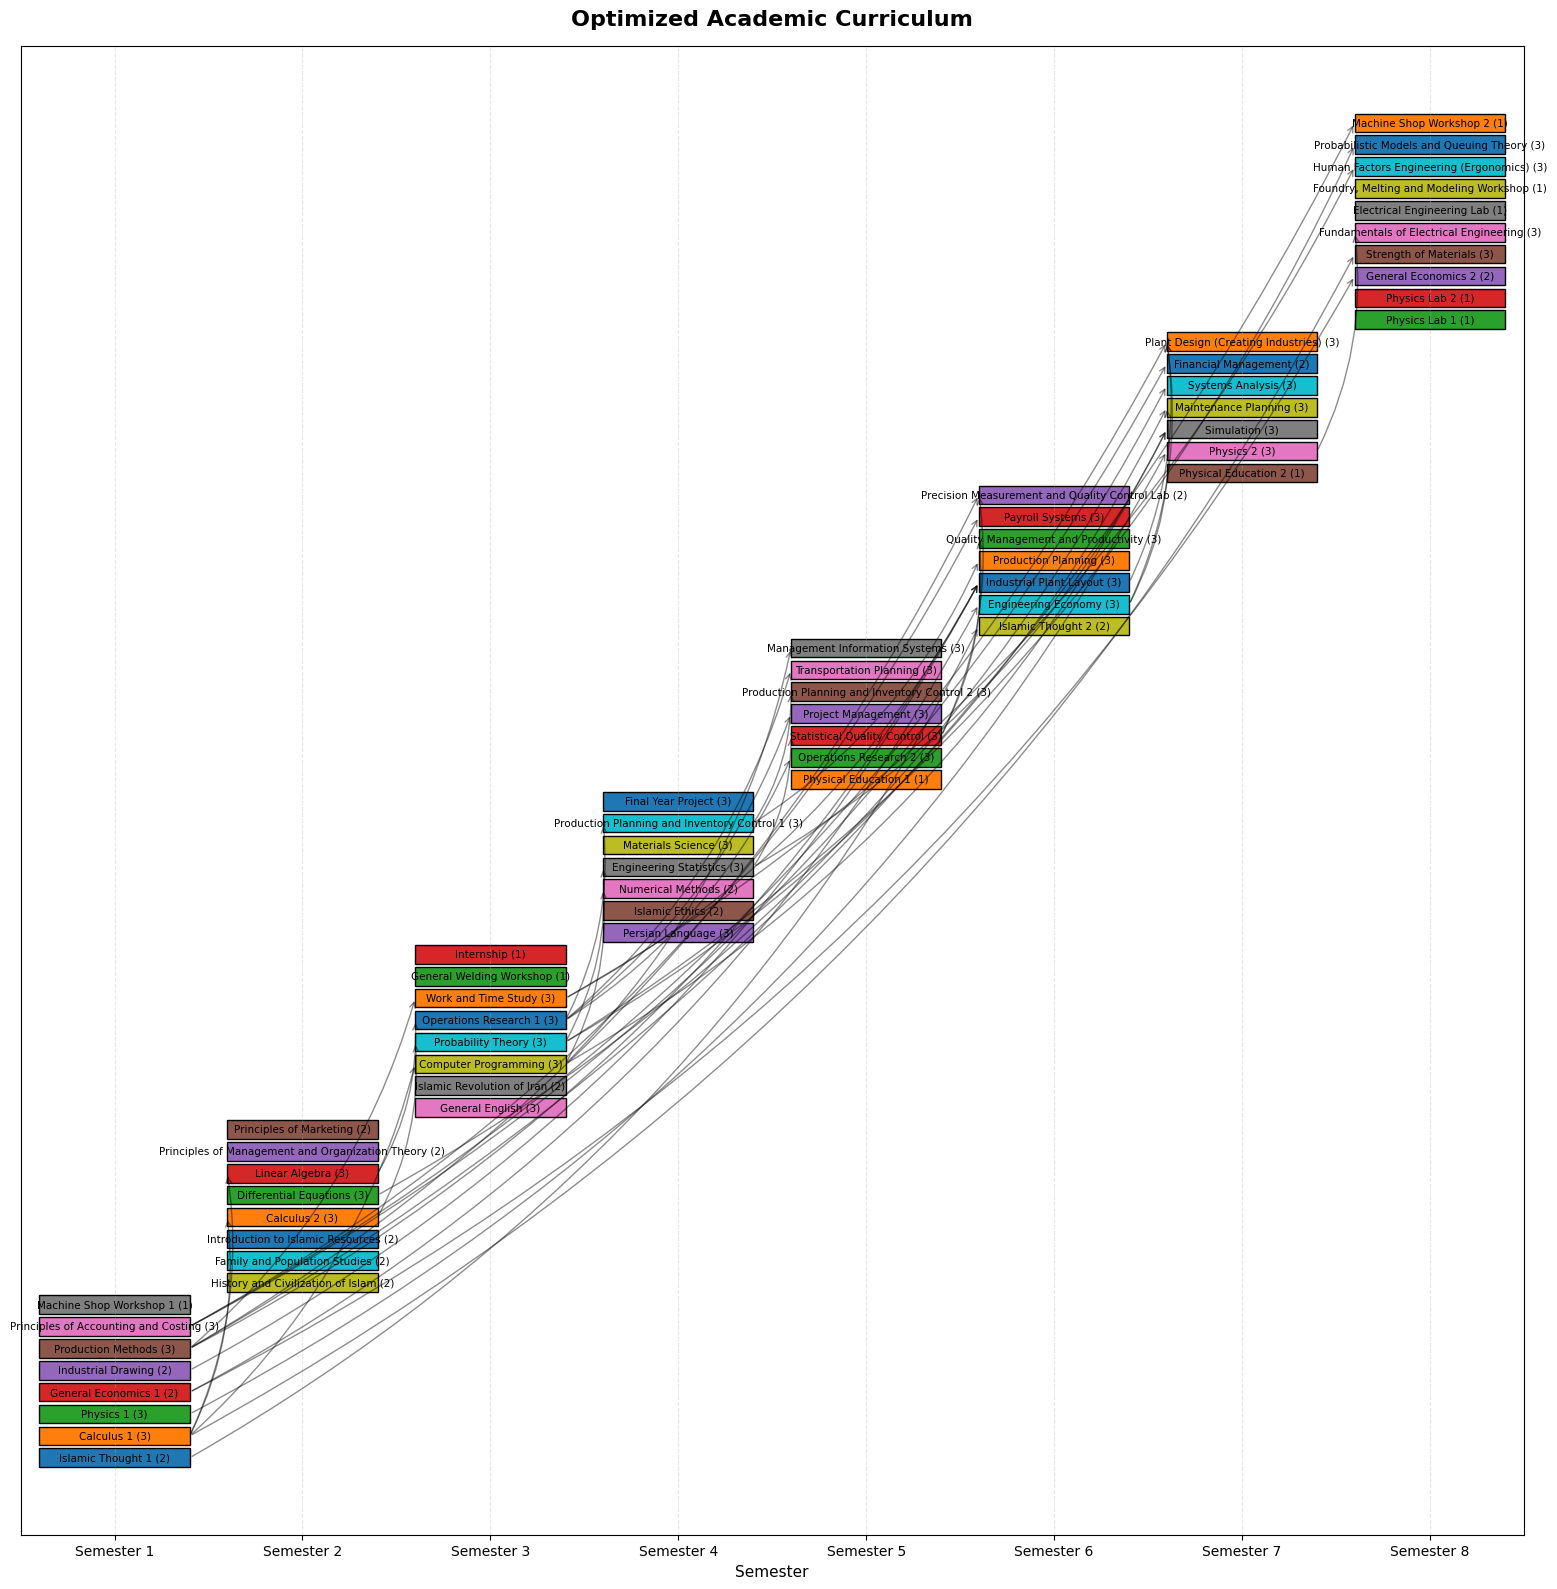

In [38]:
# Directly copy-pasted this part from AI

import matplotlib.pyplot as plt
import numpy as np

course_semester = {}

for c in num_c:
    for t in T:
        if solver.Value(x[c, t]):
            course_semester[c] = t

ordered_courses = sorted(
    num_c,
    key=lambda c: (course_semester[c], c)
)

fig, ax = plt.subplots(figsize=(16, 16))

y_positions = {
    c: i
    for i, c in enumerate(ordered_courses)
}

for c in ordered_courses:
    y = y_positions[c]
    semester = course_semester[c]

    ax.barh( y, 0.8, left=semester - 0.4, height=0.85,           
        edgecolor="black", linewidth=1.0 )

    ax.text( semester, y, f"{C[c]} ({q[c]})", ha="center",
        va="center", fontsize=7.5, fontweight="medium" )

for c1, c2 in P_strict:

    y1 = y_positions[c1]
    y2 = y_positions[c2]

    t1 = course_semester[c1]
    t2 = course_semester[c2]

    ax.annotate( "", xy=(t2 - 0.4, y2), xytext=(t1 + 0.4, y1),
        arrowprops=dict( arrowstyle="->", connectionstyle="arc3,rad=0.15",
            alpha=0.45, linewidth=1 ))

ax.set_yticks([])
ax.set_xticks(T)
ax.set_xticklabels( [f"Semester {t}" for t in T], fontsize=10 )
ax.set_xlim(0.5, len(T) + 0.5)
ax.set_xlabel( "Semester", fontsize=11 )
ax.set_title( "Optimized Academic Curriculum", fontsize=16, fontweight="bold", pad=15
)
ax.grid( axis="x", linestyle="--", alpha=0.3 )
plt.tight_layout()
plt.show()